In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyodbc

C:\Users\quent\AppData\Local\Temp\ipykernel_9336\902893996.py:42: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data_quantiles_surfaces = pd.read_sql_query(requete, conn)


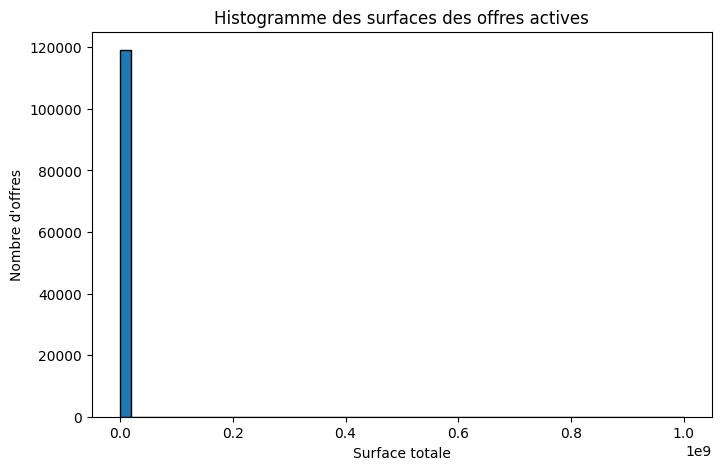

0.2     150.000000
0.4     300.000000
0.6     650.000000
0.8    1908.150024
Name: off_surface_totale, dtype: float64


In [22]:
conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=172.16.11.34;"
    "DATABASE=LogiProDev;"
    "UID=quentin;"
    "PWD={Barbidur1;SQL}"
)

conn = pyodbc.connect(conn_str)
cursor = conn.cursor()

requete = """ 
select 
    o.off_surface_totale,
    o.offre_id,
    nof.no_bureau,
    nof.no_activite,
    nof.no_commerce,
    nof.no_terrain,
    nof.no_parking,
    nof.no_habitation,
    nof.no_logistique
from
    t_offre o
inner join t_groupe g
    on g.groupe_id = o.groupe_id
    and g.groupe_id != 0
    and g.groupe_id != 2
    and g.groupe_id != 179
    and g.groupe_id != 1000
    and g.groupe_id != 165
    and g.groupe_id != 147
    and g.groupe_id != 156
    and g.gro_actif = 1
inner join tr_nature_offre nof
    on nof.nature_offre_id = o.nature_offre_id and nof.langue_id = 1
where
    o.langue_id = 1
    and o.off_actif = 1
"""

data_quantiles_surfaces = pd.read_sql_query(requete, conn)

conn.commit()
conn.close()

# seuil = data_quantiles_surfaces["off_surface_totale"].quantile(0.99)
# data_quantiles_surfaces = data_quantiles_surfaces[data_quantiles_surfaces["off_surface_totale"] <= seuil]

plt.figure(figsize=(8, 5))

plt.hist(
    data_quantiles_surfaces["off_surface_totale"].dropna(),
    bins=50,
    edgecolor="black"
)

plt.xlabel("Surface totale")
plt.ylabel("Nombre d'offres")
plt.title("Histogramme des surfaces des offres actives")

plt.show()

quantiles = data_quantiles_surfaces["off_surface_totale"].quantile([0.2, 0.4, 0.6, 0.8])
print(quantiles)

# Donc là on a les quantiles globaux, mais on ne différencie pas selon le type d'activité. 
# Ca va donner beaucoup trop de filtres dans superset si on évalue les quantiles pour chaque département
# mais on va quand même le faire pour les types d'activité, ce sera certainement plus significatif

In [23]:
# Quantiles bureaux : 
quantiles_bureaux = data_quantiles_surfaces[data_quantiles_surfaces["no_bureau"] == 1]
quantiles = quantiles_bureaux["off_surface_totale"].quantile([0.2, 0.4, 0.6, 0.8])
print(f"Bureaux : {quantiles}")

# Quantiles activite : 
quantiles_activite = data_quantiles_surfaces[data_quantiles_surfaces["no_activite"] == 1]
quantiles = quantiles_activite["off_surface_totale"].quantile([0.2, 0.4, 0.6, 0.8])
print(f"Activite : {quantiles}")

# Quantiles commerces : 
quantiles_commerce = data_quantiles_surfaces[data_quantiles_surfaces["no_commerce"] == 1]
quantiles = quantiles_commerce["off_surface_totale"].quantile([0.2, 0.4, 0.6, 0.8])
print(f"Commerce : {quantiles}")

# Quantiles habitation : 
quantiles_habitation = data_quantiles_surfaces[data_quantiles_surfaces["no_habitation"] == 1]
quantiles = quantiles_habitation["off_surface_totale"].quantile([0.2, 0.4, 0.6, 0.8])
print(f"Habitations : {quantiles}")

# Quantiles logistique : 
quantiles_logistique = data_quantiles_surfaces[data_quantiles_surfaces["no_logistique"] == 1]
quantiles = quantiles_logistique["off_surface_totale"].quantile([0.2, 0.4, 0.6, 0.8])
print(f"Logistique : {quantiles}")

# Quantiles parking : 
quantiles_parking = data_quantiles_surfaces[data_quantiles_surfaces["no_parking"] == 1]
quantiles = quantiles_parking["off_surface_totale"].quantile([0.2, 0.4, 0.6, 0.8])
print(f"Parkings : {quantiles}")

# Quantiles terrain : 
quantiles_terrain = data_quantiles_surfaces[data_quantiles_surfaces["no_bureau"] == 1]
quantiles = quantiles_terrain["off_surface_totale"].quantile([0.2, 0.4, 0.6, 0.8])
print(f"Terrains : {quantiles}")

Bureaux : 0.2     141.308005
0.4     260.000000
0.6     526.000000
0.8    1489.300000
Name: off_surface_totale, dtype: float64
Activite : 0.2     367.000000
0.4     736.800000
0.6    1530.000000
0.8    4270.875977
Name: off_surface_totale, dtype: float64
Commerce : 0.2     80.000000
0.4    143.000000
0.6    257.919995
0.8    591.000000
Name: off_surface_totale, dtype: float64
Habitations : 0.2     657.52002
0.4    1660.80000
0.6    3522.60000
0.8    6887.00000
Name: off_surface_totale, dtype: float64
Logistique : 0.2      567.0
0.4     1565.0
0.6     5448.0
0.8    14862.0
Name: off_surface_totale, dtype: float64
Parkings : 0.2       88.00000
0.4     1322.00000
0.6     3942.07998
0.8    20247.20000
Name: off_surface_totale, dtype: float64
Terrains : 0.2     141.308005
0.4     260.000000
0.6     526.000000
0.8    1489.300000
Name: off_surface_totale, dtype: float64


In [ ]:
# Requête finale pour afficher les deux graphiques du dashboards statistiques descriptives des portails

"""   
select
    lep.offre_id,
    lep.lep_date,
    lep.nat_type,
    lep.lep_prix_moyen,
    lep.lep_surface_total,
    p.por_libelle,
    p.portail_id,
    o.adresse_id,
    nof.no_bureau,
    nof.no_activite,
    nof.no_commerce,
    nof.no_terrain,
    nof.no_parking,
    nof.no_habitation,
    nof.no_logistique,
    left(a.adr_adresse_cp, 2) as departement,
    g.groupe_id,
    CASE
        WHEN lep.lep_surface_total <= 150 THEN '0-150'
        WHEN lep.lep_surface_total <= 300 THEN '150-300'
        WHEN lep.lep_surface_total <= 650 THEN '300-650'
        WHEN lep.lep_surface_total <= 1900 THEN '650-1900'
        ELSE '1900+'
    END AS quantile_surface_globale,

    CASE
        WHEN no_bureau = 1 THEN
            CASE 
                WHEN lep.lep_surface_total <= 140 THEN '0-140'
                WHEN lep.lep_surface_total <= 260 THEN '140-260'
                WHEN lep.lep_surface_total <= 525 THEN '260-525'
                WHEN lep.lep_surface_total <= 1490 THEN '525-1490'
                ELSE '1490+'
            END
        ELSE NULL
    END AS quantile_surface_bureau,

    CASE 
        WHEN no_activite = 1 THEN
            CASE
                WHEN lep.lep_surface_total <= 365 THEN '0-365'
                WHEN lep.lep_surface_total <= 735 THEN '365-735'
                WHEN lep.lep_surface_total <= 1230 THEN '735-1230'
                WHEN lep.lep_surface_total <= 4270 THEN '1230-4270'
                ELSE '4270+'
            END
        ELSE NULL
    END AS quantile_surface_activite,

    CASE
        WHEN no_commerce = 1 THEN 
            CASE
                WHEN lep.lep_surface_total <= 80 THEN '0-80'
                WHEN lep.lep_surface_total <= 145 THEN '80-145'
                WHEN lep.lep_surface_total <= 255 THEN '145-255'
                WHEN lep.lep_surface_total <= 590 THEN '255-590'
                ELSE '590+'
            END
        ELSE NULL
    END AS quantile_surface_commerce,

    CASE
        WHEN no_logistique = 1 THEN 
            CASE
                WHEN lep.lep_surface_total <= 565 THEN '0-565'
                WHEN lep.lep_surface_total <= 1565 THEN '565-1565'
                WHEN lep.lep_surface_total <= 5450 THEN '1565-5450'
                WHEN lep.lep_surface_total <= 14860 THEN '5450-14860'
                ELSE '14860+'
            END
        ELSE NULL
    END AS quantile_surface_logistique,

    CASE 
        WHEN no_habitation = 1 THEN
            CASE
                WHEN lep.lep_surface_total <= 655 THEN '0-655'
                WHEN lep.lep_surface_total <= 1660 THEN '655-1660'
                WHEN lep.lep_surface_total <= 3520 THEN '1660-3520'
                WHEN lep.lep_surface_total <= 6885 THEN '3520-6885'
                ELSE '6885+'
            END
        ELSE NULL
    END AS quantile_surface_habitation,

    CASE 
        WHEN no_terrain = 1 THEN
            CASE
                WHEN lep.lep_surface_total <= 140 THEN '0-140'
                WHEN lep.lep_surface_total <= 260 THEN '140-260'
                WHEN lep.lep_surface_total <= 525 THEN '260-525'
                WHEN lep.lep_surface_total <= 1490 THEN '525-1490'
                ELSE '1490+'
            END
        ELSE NULL
    END AS quantile_surface_terrain,

    CASE 
        WHEN no_parking = 1 THEN 
            CASE
                WHEN lep.lep_surface_total <= 90 THEN '0-90'
                WHEN lep.lep_surface_total <= 1320 THEN '90-1320'
                WHEN lep.lep_surface_total <= 3940 THEN '1320-3940'
                WHEN lep.lep_surface_total <= 20245 THEN '3940-20245'
                ELSE '20245+'
            END 
        ELSE NULL
    END AS quantile_surface_parking

from 
    t_log_export_passerelle lep
inner join tr_portail p 
    on p.portail_id = lep.portail_id and p.portail_id != 31
inner join t_offre o
    on o.offre_id = lep.offre_id and o.offre_id > 0
inner join t_groupe g
    on g.groupe_id = o.groupe_id
    and g.groupe_id != 0
    and g.groupe_id != 2
    and g.groupe_id != 179
    and g.groupe_id != 1000
    and g.groupe_id != 165
    and g.groupe_id != 147
    and g.groupe_id != 156
inner join t_adresse a
    on a.adresse_id = o.adresse_id
inner join tr_nature_offre nof
    on nof.nature_offre_id = o.nature_offre_id and nof.langue_id = 1
where
    lep.langue_id = 1;
"""